In [ ]:
#Phan 1

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

class ModelOriginal(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class ModelWider(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class ModelDeeper(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

def train_model(model, criterion, optimizer, epochs=500):
    loss_history, acc_history = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = (model(X_test) > 0.5).float()
            acc = (test_pred == y_test).float().mean().item()
        loss_history.append(loss.item())
        acc_history.append(acc)
    return loss_history, acc_history

criterion = nn.BCELoss()

m_orig = ModelOriginal()
opt_orig = optim.Adam(m_orig.parameters(), lr=0.01)
loss_orig, acc_orig = train_model(m_orig, criterion, opt_orig)

m_wider = ModelWider()
opt_wider = optim.Adam(m_wider.parameters(), lr=0.01)
loss_wider, acc_wider = train_model(m_wider, criterion, opt_wider)

m_deeper = ModelDeeper()
opt_deeper = optim.Adam(m_deeper.parameters(), lr=0.01)
loss_deeper, acc_deeper = train_model(m_deeper, criterion, opt_deeper)

print(f"Mô hình gốc (4 nút ẩn)      -> Loss cuối: {loss_orig[-1]:.4f} | Test Acc: {acc_orig[-1]*100:.2f}%")
print(f"Mô hình rộng hơn (8 nút ẩn)  -> Loss cuối: {loss_wider[-1]:.4f} | Test Acc: {acc_wider[-1]*100:.2f}%")
print(f"Mô hình sâu hơn (8+6 nút ẩn) -> Loss cuối: {loss_deeper[-1]:.4f} | Test Acc: {acc_deeper[-1]*100:.2f}%")

Mô hình gốc (4 nút ẩn)      -> Loss cuối: 0.0364 | Test Acc: 98.33%
Mô hình rộng hơn (8 nút ẩn)  -> Loss cuối: 0.0065 | Test Acc: 100.00%
Mô hình sâu hơn (8+6 nút ẩn) -> Loss cuối: 0.0004 | Test Acc: 100.00%


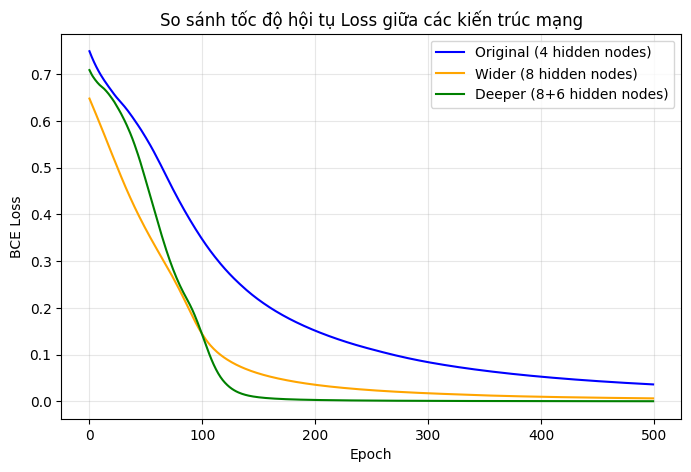

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(loss_orig, label='Original (4 hidden nodes)', color='blue')
plt.plot(loss_wider, label='Wider (8 hidden nodes)', color='orange')
plt.plot(loss_deeper, label='Deeper (8+6 hidden nodes)', color='green')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('So sánh tốc độ hội tụ Loss giữa các kiến trúc mạng')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Phan 2

In [3]:
class ModelLogits(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x): return self.net(x)

m_logits = ModelLogits()
criterion_logits = nn.BCEWithLogitsLoss()
opt_logits = optim.Adam(m_logits.parameters(), lr=0.01)

loss_logits = []
for epoch in range(500):
    m_logits.train()
    opt_logits.zero_grad()
    outputs = m_logits(X_train)
    loss = criterion_logits(outputs, y_train)
    loss.backward()
    opt_logits.step()
    loss_logits.append(loss.item())

m_logits.eval()
with torch.no_grad():
    test_proba = torch.sigmoid(m_logits(X_test))
    pred_logits = (test_proba > 0.5).float()
    acc_logits = (pred_logits == y_test).float().mean().item()

print(f"Accuracy khi dùng BCEWithLogitsLoss: {acc_logits*100:.2f}%")

Accuracy khi dùng BCEWithLogitsLoss: 100.00%


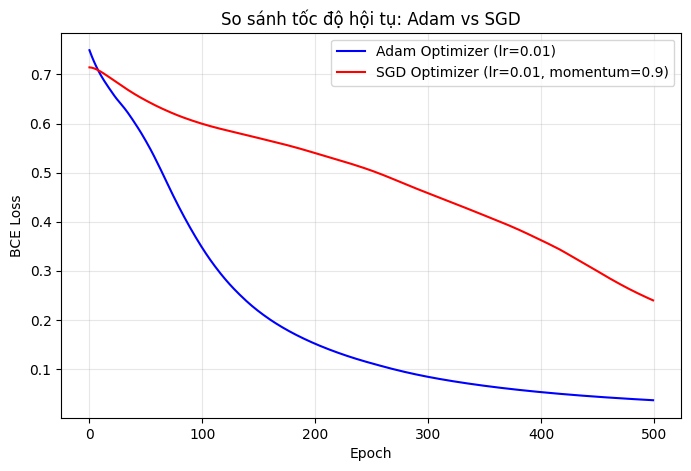

In [4]:
m_sgd = ModelOriginal() # Dùng lại kiến trúc chuẩn ban đầu
opt_sgd = optim.SGD(m_sgd.parameters(), lr=0.01, momentum=0.9)
loss_sgd, acc_sgd = train_model(m_sgd, criterion, opt_sgd)

# Vẽ đồ thị trực quan so sánh giữa Adam và SGD
plt.figure(figsize=(8, 5))
plt.plot(loss_orig, label='Adam Optimizer (lr=0.01)', color='blue')
plt.plot(loss_sgd, label='SGD Optimizer (lr=0.01, momentum=0.9)', color='red')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('So sánh tốc độ hội tụ: Adam vs SGD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Phan 3

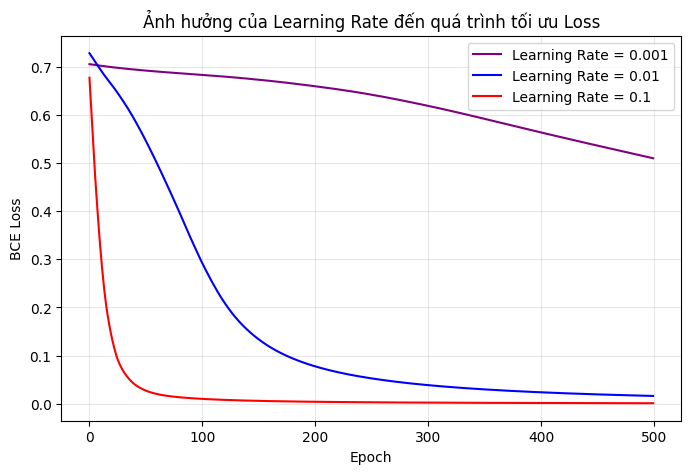

In [5]:
lrs = [0.001, 0.01, 0.1]
colors = ['purple', 'blue', 'red']
plt.figure(figsize=(8, 5))

for lr, color in zip(lrs, colors):
    m_lr = ModelOriginal()
    opt_lr = optim.Adam(m_lr.parameters(), lr=lr)
    loss_lr, _ = train_model(m_lr, criterion, opt_lr)
    plt.plot(loss_lr, label=f'Learning Rate = {lr}', color=color)

plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Ảnh hưởng của Learning Rate đến quá trình tối ưu Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

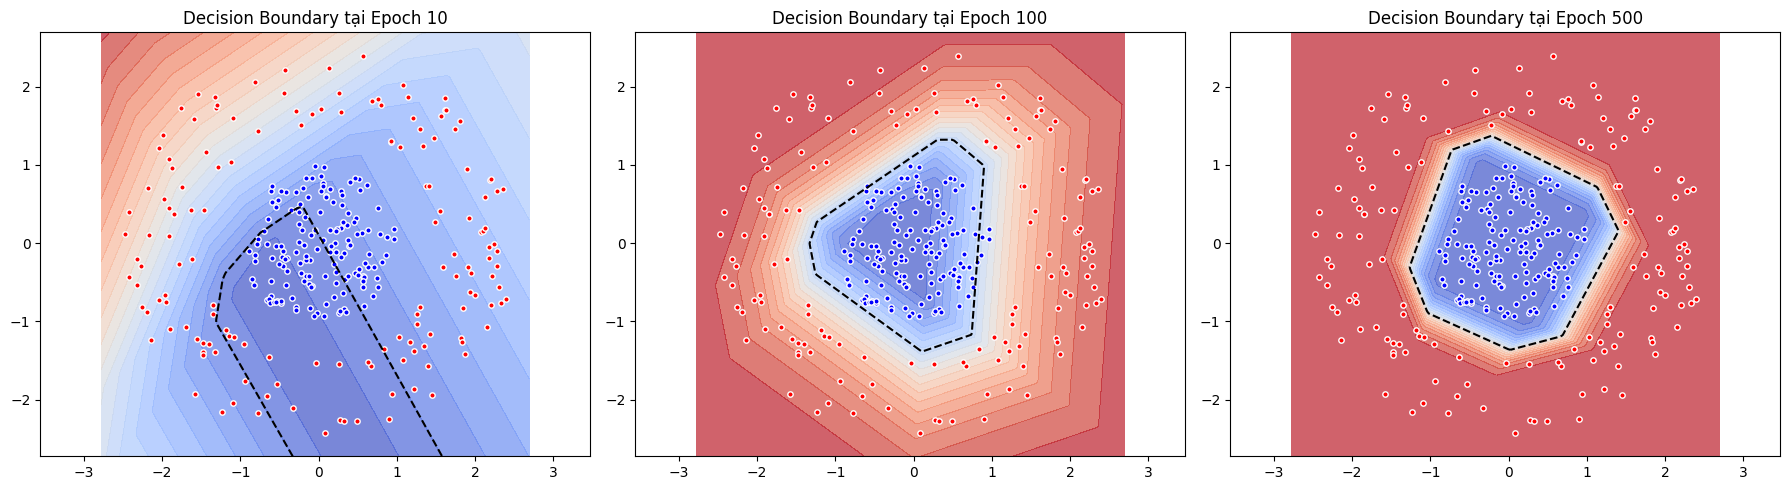

In [6]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

m_track = ModelOriginal()
opt_track = optim.Adam(m_track.parameters(), lr=0.01)

target_epochs = [10, 100, 500]
saved_probas = {}

for epoch in range(1, 501):
    m_track.train()
    opt_track.zero_grad()
    outputs = m_track(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    opt_track.step()

    if epoch in target_epochs:
        m_track.eval()
        with torch.no_grad():
            proba = m_track(grid).numpy().reshape(xx.shape)
            saved_probas[epoch] = proba

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, epoch in enumerate(target_epochs):
    proba = saved_probas[epoch]
    axes[i].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.7)
    axes[i].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=15, label='Class 0')
    axes[i].scatter(X1[:, 0], X1[:, 1], color='red', edgecolor='white', s=15, label='Class 1')
    axes[i].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
    axes[i].set_title(f'Decision Boundary tại Epoch {epoch}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()